In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Step 1: Define 5x5 Binary Templates for Digits '0' and '1'
# 1 represents a filled pixel (black), -1 represents background (white)
digit_0 = np.array(
    [
        [-1, 1, 1, 1, -1],
        [1, -1, -1, -1, 1],
        [1, -1, -1, -1, 1],
        [1, -1, -1, -1, 1],
        [-1, 1, 1, 1, -1],
    ]
).flatten()

digit_1 = np.array(
    [
        [-1, -1, 1, -1, -1],
        [-1, 1, 1, -1, -1],
        [-1, -1, 1, -1, -1],
        [-1, -1, 1, -1, -1],
        [-1, 1, 1, 1, -1],
    ]
).flatten()

In [4]:
# Store patterns inside a list
stored_patterns = [digit_0, digit_1]
N = len(digit_0)  # Number of neurons (5x5 = 25)

In [6]:
# Step 2: Train the Network (Compute the Weight Matrix using Hebbian Learning)
def train(patterns):
    num_patterns = len(patterns)
    # Initialize an NxN zero matrix
    W = np.zeros((N, N))

    for p in patterns:
        # Outer product to find correlations between pixels
        W += np.outer(p, p)

    # Average the weights and force self-connections to be 0 (no self-loops)
    W /= num_patterns
    np.fill_diagonal(W, 0)
    return W

In [7]:
# Step 3: Pattern Retrieval / Reconstruction (Asynchronous Update)
def recall(noisy_pattern, W, steps=5):
    state = np.copy(noisy_pattern)

    # Asynchronously update individual neurons across several iterations
    for _ in range(steps):
        # Update neurons in random order to guarantee convergence
        indices = np.arange(N)
        np.random.shuffle(indices)

        for i in indices:
            # Activation function: s_i = sgn(sum(W_ij * s_j))
            raw_input = np.dot(W[i], state)
            state[i] = 1 if raw_input >= 0 else -1

    return state

In [15]:
# --- Execution Flow ---

# 1. Train the network weights
W = train(stored_patterns)

# 2. Create a corrupted test case (Take digit '0' and flip random pixels)
noisy_digit_0 = np.copy(digit_0)
noise_indices = [6, 7, 13, 17]  # Pick index positions to ruin [6, 7, 12, 17]
for idx in noise_indices:
    noisy_digit_0[idx] *= -1  # Invert the pixel value

# 3. Ask the Hopfield network to repair the corrupted image
reconstructed_digit_0 = recall(noisy_digit_0, W)


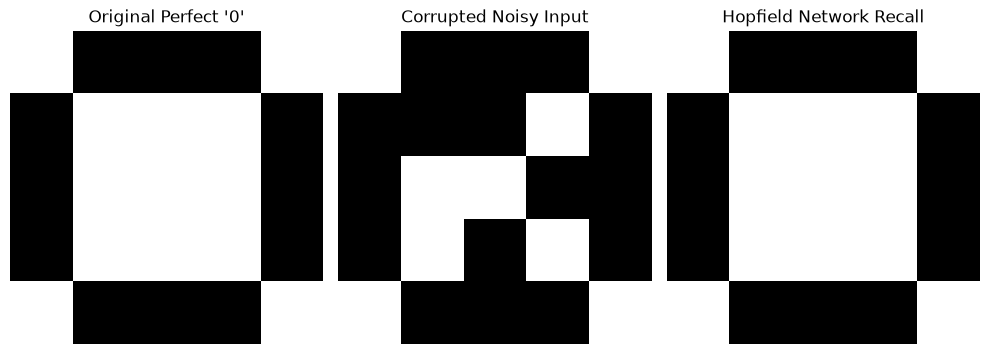

In [16]:
# Step 4: Visualize the Results
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(digit_0.reshape(5, 5), cmap="binary")
axes[0].set_title("Original Perfect '0'")
axes[0].axis("off")

axes[1].imshow(noisy_digit_0.reshape(5, 5), cmap="binary")
axes[1].set_title("Corrupted Noisy Input")
axes[1].axis("off")

axes[2].imshow(reconstructed_digit_0.reshape(5, 5), cmap="binary")
axes[2].set_title("Hopfield Network Recall")
axes[2].axis("off")

plt.tight_layout()
plt.show()